# 07. Marked Price Index (Steps 04 → 06.1)

Replicates the full pipeline using **`marked_price`** (original sticker price) instead of `final_price` (discounted checkout price).

**Price rule:** use `marked_price` when available; fall back to `final_price` when `marked_price` is NaN or zero (non-promoted products, where sticker price = checkout price).

**Step 04 categorization is reused as-is** — `cat_lookup_table.csv` files are unchanged.

### Outputs
- `output/marked_price_overall_daily_average_index.csv`
- `output/marked_price_other_food_mom_change.csv`
- `output/marked_price_cpi_nowcasting_dashboard.png`
- `output/marked_vs_final_price_comparison.png`
- `output/marked_price_subcategory_kmeans_groups.csv`

In [1]:
from pathlib import Path
ROOT = Path().resolve().parent  # notebooks/ -> repo root
DATA = ROOT / 'data'
OUT  = ROOT / 'output'

In [2]:
import re
import json
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import gmean
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

CATEGORIES = [
    'Dairy', 'Veg_Fruit', 'Dry_Food', 'Instant_food', 'Processed_food',
    'Frozen', 'Egg_and_soy', 'Confectionary', 'Spice', 'Baby_product',
]
STAPLES     = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
BABY_TARGET = 'Sữa Bột - Sữa Dinh Dưỡng'
JSON_PATH   = ROOT / 'official_cpi.json'

In [3]:
def extract_date(filename):
    m = re.search(r'\d{4}-\d{2}-\d{2}', str(filename))
    return m.group(0) if m else str(filename)


def resolve_marked_price(df):
    """
    Return effective sticker price per row.
    Uses marked_price when valid (not NaN, > 0).
    Falls back to final_price for non-promoted products
    (where marked_price is NaN, meaning sticker == checkout price).
    """
    mp = pd.to_numeric(df['marked_price'], errors='coerce')
    fp = pd.to_numeric(df['final_price'],  errors='coerce')
    return mp.where(mp.notna() & (mp > 0), other=fp)

---
## Section 1: Per-Category Jevons Index — Step 04 Equivalent
Chain-link Jevons index per subcategory, computed with `marked_price`.  
Logic mirrors `src/index_core.py`; only the price column changes.

In [4]:
def compute_jevons_for_category(
    folder_name,
    dedup_lookup=False,
    handle_new_subcats=False,
    sort_output_columns=False,
):
    """
    Chain-link Jevons index for one category using marked_price.
    Returns DataFrame(date, subcat1, subcat2, ...) or empty DataFrame on failure.
    """
    folder      = DATA / folder_name
    csv_folder  = folder / 'CSV'
    lookup_file = folder / 'cat_lookup_table.csv'

    if not lookup_file.exists():
        print(f'[WARN] lookup not found: {lookup_file}')
        return pd.DataFrame()

    lookup = pd.read_csv(lookup_file, usecols=['product_name', 'subcategory'])
    if dedup_lookup:
        lookup = lookup.drop_duplicates(subset=['product_name'], keep='last')

    files = sorted(csv_folder.glob('*.csv'))
    if not files:
        print(f'[WARN] no CSV files in {csv_folder}')
        return pd.DataFrame()

    history   = {}
    prev_df   = None
    prev_date = None
    results   = []

    for file in files:
        current_date = extract_date(file.name)
        try:
            raw = pd.read_csv(file, usecols=['product_name', 'final_price', 'marked_price'])
            raw['price'] = resolve_marked_price(raw)
            curr_df = raw[['product_name', 'price']].copy()
            curr_df = curr_df.merge(lookup, on='product_name', how='left')
            curr_df = curr_df.dropna(subset=['subcategory', 'price'])
            curr_df = curr_df[curr_df['price'] > 0]

            if prev_df is None:
                day_results = {'date': current_date}
                for sub in curr_df['subcategory'].unique():
                    history[sub] = {current_date: 1.0}
                    day_results[sub] = 1.0
                results.append(day_results)
            else:
                day_results = {'date': current_date}
                for sub in history:
                    p_prev = prev_df[prev_df['subcategory'] == sub][['product_name', 'price']]
                    p_curr = curr_df[curr_df['subcategory'] == sub][['product_name', 'price']]
                    matched = p_prev.merge(p_curr, on='product_name', suffixes=('_prev', '_curr'))
                    matched = matched[(matched['price_prev'] > 0) & (matched['price_curr'] > 0)]

                    if not matched.empty:
                        relatives = matched['price_curr'] / matched['price_prev']
                        new_index = history[sub].get(prev_date, 1.0) * gmean(relatives)
                        history[sub][current_date] = new_index
                    else:
                        history[sub][current_date] = history[sub].get(prev_date, 1.0)

                    day_results[sub] = history[sub][current_date]

                if handle_new_subcats:
                    for sub in curr_df['subcategory'].unique():
                        if sub not in history:
                            history[sub] = {current_date: 1.0}
                            day_results[sub] = 1.0

                results.append(day_results)

            prev_df   = curr_df
            prev_date = current_date

        except Exception as e:
            print(f'  [ERROR] {file.name}: {e}')

    if not results:
        return pd.DataFrame()

    out = pd.DataFrame(results)
    if sort_output_columns:
        cols = ['date'] + sorted(c for c in out.columns if c != 'date')
        out = out[cols]
    return out

In [5]:
# Processed_food needs special flags (mirrors mass_categorize_index.py)
CATEGORY_FLAGS = {
    'Processed_food': dict(dedup_lookup=True, handle_new_subcats=True, sort_output_columns=True),
}

cat_indices = {}

for cat in CATEGORIES:
    flags = CATEGORY_FLAGS.get(cat, {})
    print(f'Processing {cat}...')
    df = compute_jevons_for_category(cat, **flags)
    if df.empty:
        print(f'  [SKIP] {cat} produced no output')
    else:
        cat_indices[cat] = df
        print(f'  done — {len(df)} dates, {len(df.columns)-1} subcategories')

print(f'\nDone. {len(cat_indices)}/{len(CATEGORIES)} categories computed.')

Processing Dairy...


  done — 92 dates, 6 subcategories
Processing Veg_Fruit...


  done — 92 dates, 3 subcategories
Processing Dry_Food...


  done — 92 dates, 6 subcategories
Processing Instant_food...


  done — 76 dates, 1 subcategories
Processing Processed_food...


  done — 91 dates, 5 subcategories
Processing Frozen...


  done — 93 dates, 5 subcategories
Processing Egg_and_soy...


  done — 90 dates, 2 subcategories
Processing Confectionary...


  done — 49 dates, 4 subcategories
Processing Spice...
[WARN] lookup not found: /Users/my/Online Food Price/data/Spice/cat_lookup_table.csv
  [SKIP] Spice produced no output
Processing Baby_product...


  done — 93 dates, 4 subcategories

Done. 9/10 categories computed.


---
## Section 2: Aggregate to Overall / Staples / Other Food — Step 05 Equivalent
Mirrors `05. food_index.py`.  
Staples = Gạo-Nông Sản Khô + Ngũ Cốc-Yến Mạch; Baby_product → Sữa Bột only.

In [6]:
all_sub_dfs = []

for cat, df in cat_indices.items():
    sub_df = df.set_index('date')

    if cat == 'Baby_product':
        if BABY_TARGET in sub_df.columns:
            sub_df = sub_df[[BABY_TARGET]]
        else:
            print(f'[WARN] Baby_product: "{BABY_TARGET}" not found — skipping')
            continue

    # Average duplicate dates (shouldn't happen, but mirrors food_index.py)
    sub_df = sub_df.groupby('date').mean()
    all_sub_dfs.append(sub_df)

combined = pd.concat(all_sub_dfs, axis=1)
combined = combined.loc[:, ~combined.columns.duplicated()]  # drop duplicate cols

staple_cols = [c for c in combined.columns if c in STAPLES]
other_cols  = [c for c in combined.columns if c not in STAPLES]

final_agg = pd.DataFrame(index=combined.index)
final_agg['overall_average_index']    = combined.mean(axis=1)
final_agg['staples_average_index']    = combined[staple_cols].mean(axis=1) if staple_cols else np.nan
final_agg['other_food_average_index'] = combined[other_cols].mean(axis=1) if other_cols else np.nan

final_agg.reset_index(inplace=True)
final_agg.sort_values('date', inplace=True)

out_path = OUT / 'marked_price_overall_daily_average_index.csv'
final_agg.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(final_agg.head())

Saved: /Users/my/Online Food Price/output/marked_price_overall_daily_average_index.csv
         date  overall_average_index  staples_average_index  \
0  2025-12-18               1.000000                    1.0   
1  2025-12-19               0.998921                    1.0   
2  2025-12-20               0.998718                    1.0   
3  2025-12-22               0.998571                    1.0   
4  2025-12-23               0.996732                    1.0   

   other_food_average_index  
0                  1.000000  
1                  0.998841  
2                  0.998623  
3                  0.998465  
4                  0.996490  


---
## Section 3: Month-over-Month Index for Other Food — Step 04.1 Equivalent
Mirrors `04.1. mass_MoM_index.py`.  
Excludes staples; Baby_product → Sữa Bột only.  
MoM ratio = gmean(P_current / P_same_date_minus_1_month) per subcategory.

In [7]:
historical_dfs = {}  # date_str -> DataFrame(product_name, price, subcategory)

for cat in CATEGORIES:
    csv_folder  = DATA / cat / 'CSV'
    lookup_file = DATA / cat / 'cat_lookup_table.csv'

    if not csv_folder.exists() or not lookup_file.exists():
        continue

    try:
        lookup = pd.read_csv(lookup_file, usecols=['product_name', 'subcategory'])
    except Exception as e:
        print(f'[WARN] lookup read error {cat}: {e}')
        continue

    for file_path in csv_folder.glob('*.csv'):
        current_date = extract_date(file_path.name)
        try:
            raw = pd.read_csv(file_path, usecols=['product_name', 'final_price', 'marked_price'])
            raw['price'] = resolve_marked_price(raw)
            df = raw[['product_name', 'price']].copy()
            df = df.merge(lookup, on='product_name', how='left')
            df = df.dropna(subset=['subcategory', 'price'])
            df = df[df['price'] > 0]

            if cat == 'Baby_product':
                df = df[df['subcategory'] == BABY_TARGET]
            else:
                df = df[~df['subcategory'].isin(STAPLES)]

            if df.empty:
                continue

            if current_date not in historical_dfs:
                historical_dfs[current_date] = []
            historical_dfs[current_date].append(df)

        except Exception:
            pass

for d in list(historical_dfs.keys()):
    historical_dfs[d] = pd.concat(historical_dfs[d], ignore_index=True)

print(f'Loaded {len(historical_dfs)} dates into pool.')

Loaded 94 dates into pool.


In [8]:
dates   = sorted(historical_dfs.keys())
results = []

for current_date in dates:
    curr_df       = historical_dfs[current_date]
    past_date_str = (pd.to_datetime(current_date) - pd.DateOffset(months=1)).strftime('%Y-%m-%d')
    day_results   = {'date': current_date}

    if past_date_str in historical_dfs:
        past_df = historical_dfs[past_date_str]
        for sub in curr_df['subcategory'].unique():
            p_past = past_df[past_df['subcategory'] == sub][['product_name', 'price']]
            p_curr = curr_df[curr_df['subcategory'] == sub][['product_name', 'price']]
            matched = p_past.merge(p_curr, on='product_name', suffixes=('_past', '_curr'))
            matched = matched[(matched['price_past'] > 0) & (matched['price_curr'] > 0)]
            if not matched.empty:
                day_results[sub] = gmean(matched['price_curr'] / matched['price_past'])
            else:
                day_results[sub] = np.nan
    else:
        for sub in curr_df['subcategory'].unique():
            day_results[sub] = np.nan

    results.append(day_results)

mom_df = pd.DataFrame(results)
sub_cols = [c for c in mom_df.columns if c != 'date']
mom_df['other_food_average'] = mom_df[sub_cols].mean(axis=1)
mom_df.sort_values('date', inplace=True)

mom_out = OUT / 'marked_price_other_food_mom_change.csv'
mom_df.to_csv(mom_out, index=False, encoding='utf-8-sig')
print(f'Saved: {mom_out}')
print(mom_df[['date', 'other_food_average']].tail())

Saved: /Users/my/Online Food Price/output/marked_price_other_food_mom_change.csv
          date  other_food_average
89  2026-03-18            1.002886
90  2026-03-19            1.004262
91  2026-03-20            1.004766
92  2026-03-21            1.001808
93  2026-03-22            1.003522


---
## Section 4: CPI Nowcasting Dashboard — Step 06 Equivalent
4-panel dashboard mirroring `notebooks/06. visualize.ipynb`, using marked_price indices.

In [9]:
def align_axes(ax1, ax2):
    """Force both axes to share the same scale."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    final_min = min(y1_min, y2_min)
    final_max = max(y1_max, y2_max)
    pad = (final_max - final_min) * 0.05
    ax1.set_ylim(final_min - pad, final_max + pad)
    ax2.set_ylim(final_min - pad, final_max + pad)


def add_official_cpi_lines(ax, cpi_data, category_key, color):
    """Horizontal dashed lines spanning each calendar month for official MoM CPI."""
    ax2 = ax.twinx()
    for month_str, values in cpi_data.items():
        if month_str == '2025-12':
            continue
        start_date = pd.to_datetime(f'{month_str}-01')
        end_date   = start_date + pd.offsets.MonthEnd(1)
        mom_pct    = values.get(category_key)
        if mom_pct is not None:
            ax2.hlines(y=mom_pct, xmin=start_date, xmax=end_date,
                       color=color, linestyle='--', linewidth=2.5, alpha=0.7,
                       label=f'Official {month_str} ({mom_pct}%)')
            ax2.text(start_date, mom_pct + 0.02, f'+{mom_pct}%', color=color, fontweight='bold')
    ax2.set_ylabel('Official MoM Change (%)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    return ax2

Saved: marked_price_cpi_nowcasting_dashboard.png


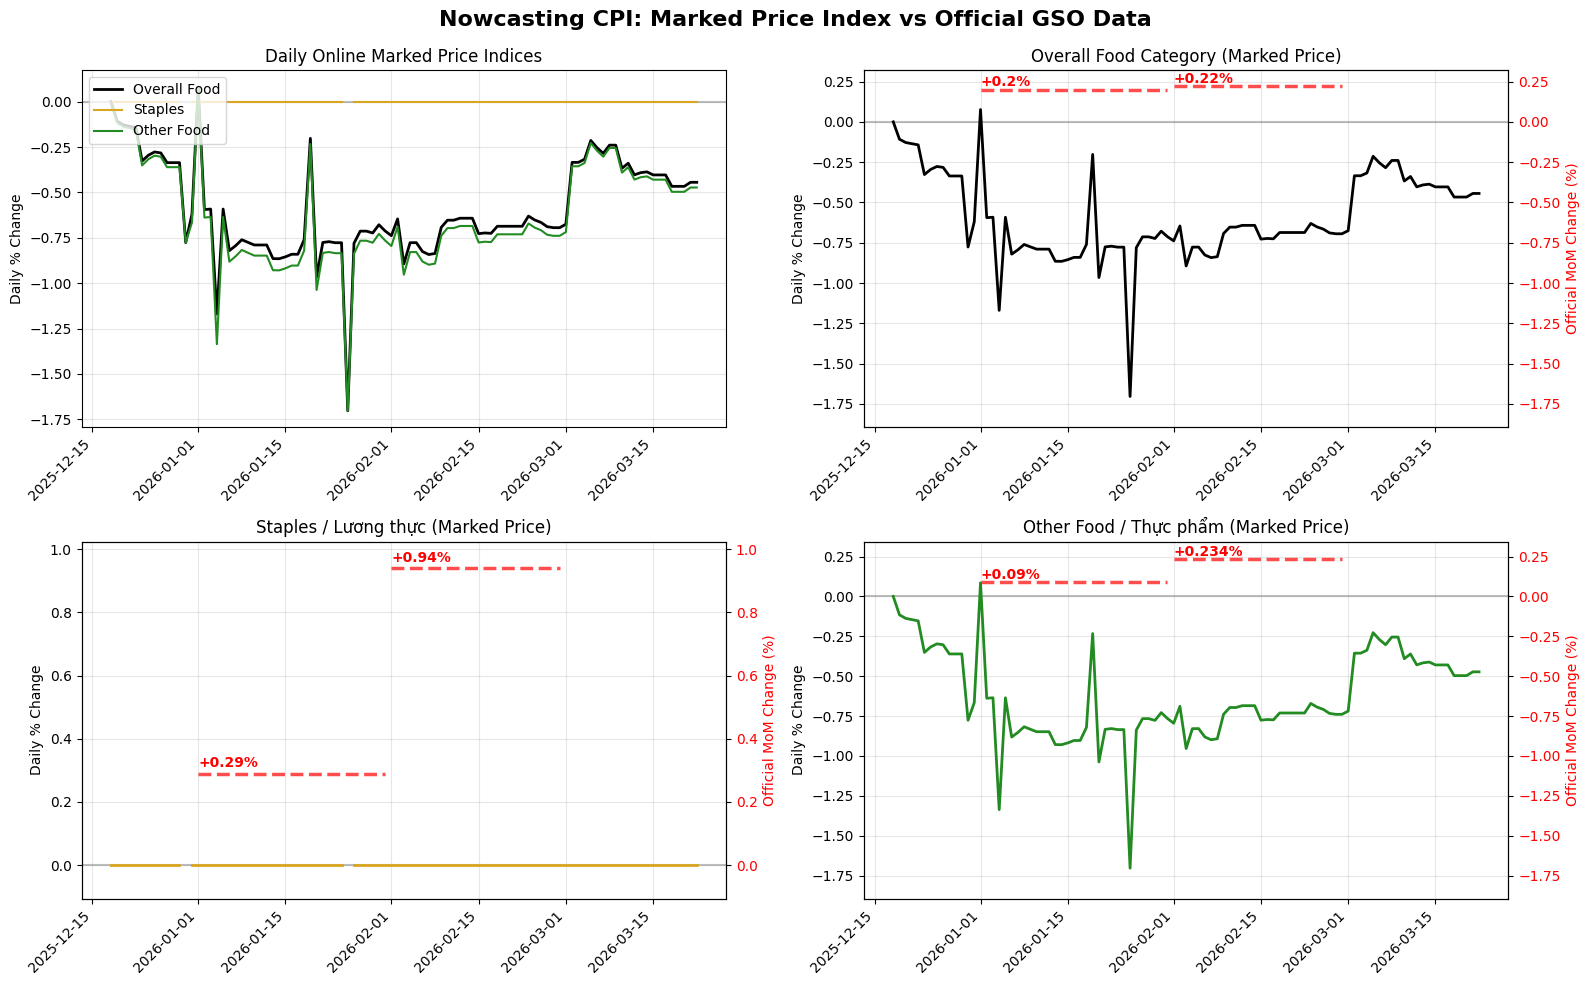

In [10]:
mp_df = pd.read_csv(OUT / 'marked_price_overall_daily_average_index.csv', parse_dates=['date'])
with open(JSON_PATH) as f:
    cpi_data = json.load(f)['official_cpi_mom_pct']

for col in ['overall_average_index', 'staples_average_index', 'other_food_average_index']:
    if col in mp_df.columns:
        mp_df[col] = (mp_df[col] - 1) * 100

date_fmt = mdates.DateFormatter('%Y-%m-%d')
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Nowcasting CPI: Marked Price Index vs Official GSO Data', fontsize=16, fontweight='bold')

def zero_line(ax):
    ax.axhline(0, color='gray', linewidth=1.5, alpha=0.5)

# Chart 1: All three lines
ax1 = axs[0, 0]
zero_line(ax1)
ax1.plot(mp_df['date'], mp_df['overall_average_index'],    color='black',       linewidth=2, label='Overall Food')
ax1.plot(mp_df['date'], mp_df['staples_average_index'],    color='goldenrod',   linewidth=1.5, label='Staples')
ax1.plot(mp_df['date'], mp_df['other_food_average_index'], color='forestgreen', linewidth=1.5, label='Other Food')
ax1.set_title('Daily Online Marked Price Indices')
ax1.set_ylabel('Daily % Change')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Chart 2: Overall vs official CPI
ax2 = axs[0, 1]
zero_line(ax2)
ax2.plot(mp_df['date'], mp_df['overall_average_index'], color='black', linewidth=2)
ax2.set_title('Overall Food Category (Marked Price)')
ax2.set_ylabel('Daily % Change')
ax2t = add_official_cpi_lines(ax2, cpi_data, 'overall_food', 'red')
align_axes(ax2, ax2t)
ax2.grid(True, alpha=0.3)

# Chart 3: Staples vs official CPI
ax3 = axs[1, 0]
zero_line(ax3)
if 'staples_average_index' in mp_df.columns:
    ax3.plot(mp_df['date'], mp_df['staples_average_index'], color='goldenrod', linewidth=2)
    ax3.set_title('Staples / Lương thực (Marked Price)')
    ax3.set_ylabel('Daily % Change')
    ax3t = add_official_cpi_lines(ax3, cpi_data, 'staples', 'red')
    align_axes(ax3, ax3t)
ax3.grid(True, alpha=0.3)

# Chart 4: Other Food vs official CPI
ax4 = axs[1, 1]
zero_line(ax4)
if 'other_food_average_index' in mp_df.columns:
    ax4.plot(mp_df['date'], mp_df['other_food_average_index'], color='forestgreen', linewidth=2)
    ax4.set_title('Other Food / Thực phẩm (Marked Price)')
    ax4.set_ylabel('Daily % Change')
    ax4t = add_official_cpi_lines(ax4, cpi_data, 'thuc_pham', 'red')
    align_axes(ax4, ax4t)
ax4.grid(True, alpha=0.3)

for ax in axs.flat:
    ax.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(OUT / 'marked_price_cpi_nowcasting_dashboard.png', dpi=300, bbox_inches='tight')
print('Saved: marked_price_cpi_nowcasting_dashboard.png')
plt.show()

---
## Section 5: Marked Price vs Final Price — Comparison
Direct visual comparison of marked_price index vs the existing final_price index.  
Reads `output/overall_daily_average_index.csv` (final_price baseline, from Step 05).

Saved: marked_vs_final_price_comparison.png


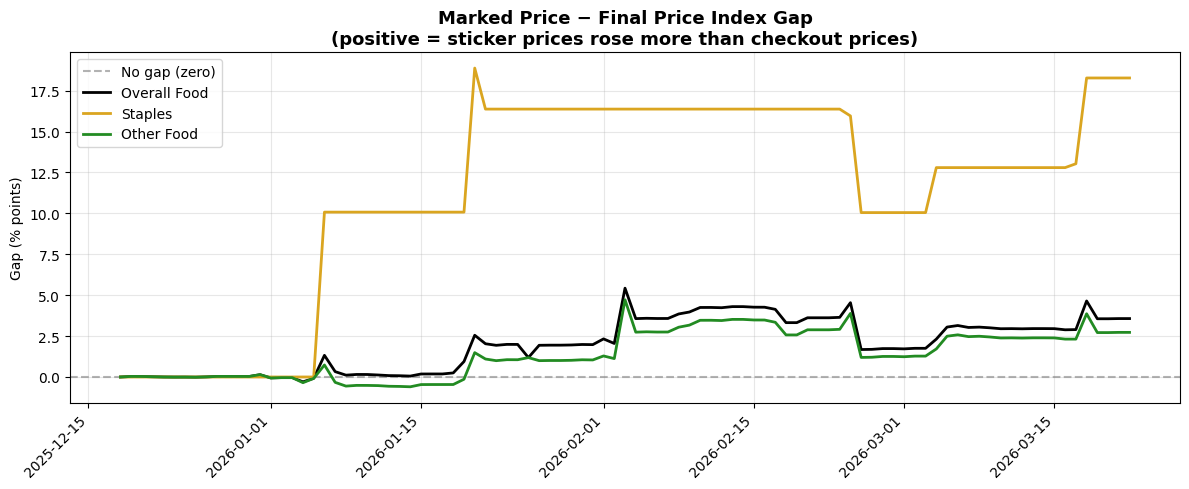


Comparison at 2026-03-22


,Index,Final Price %,Marked Price %,Gap (Marked − Final),Interpretation
0,Overall Food,-4.0142,-0.4442,3.5701,Promotions masked price rise
1,Staples,-18.2727,0.0000,18.2727,Promotions masked price rise
2,Other Food,-3.1995,-0.4728,2.7266,Promotions masked price rise


In [11]:
fp_path = OUT / 'overall_daily_average_index.csv'
if not fp_path.exists():
    print('[WARN] overall_daily_average_index.csv not found — run steps 04-05 first.')
else:
    fp_df  = pd.read_csv(fp_path, parse_dates=['date'])
    mp_df2 = pd.read_csv(OUT / 'marked_price_overall_daily_average_index.csv', parse_dates=['date'])

    cols = ['overall_average_index', 'staples_average_index', 'other_food_average_index']
    for col in cols:
        if col in fp_df.columns:
            fp_df[col]  = (fp_df[col]  - 1) * 100
        if col in mp_df2.columns:
            mp_df2[col] = (mp_df2[col] - 1) * 100

    merged = fp_df[['date'] + [c for c in cols if c in fp_df.columns]].merge(
        mp_df2[['date'] + [c for c in cols if c in mp_df2.columns]],
        on='date', suffixes=('_fp', '_mp')
    )

    panel_map = [
        ('overall_average_index',    'Overall Food', 'black'),
        ('staples_average_index',    'Staples',      'goldenrod'),
        ('other_food_average_index', 'Other Food',   'forestgreen'),
    ]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.axhline(0, color='gray', linewidth=1.5, linestyle='--', alpha=0.6, label='No gap (zero)')

    for col, label, color in panel_map:
        fp_col = col + '_fp'
        mp_col = col + '_mp'
        if fp_col in merged.columns and mp_col in merged.columns:
            gap = merged[mp_col] - merged[fp_col]
            valid = merged[['date']].assign(gap=gap).dropna()
            ax.plot(valid['date'], valid['gap'], color=color, linewidth=2, label=label)

    ax.set_title(
        'Marked Price − Final Price Index Gap\n'
        '(positive = sticker prices rose more than checkout prices)',
        fontsize=13, fontweight='bold'
    )
    ax.set_ylabel('Gap (% points)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUT / 'marked_vs_final_price_comparison.png', dpi=300, bbox_inches='tight')
    print('Saved: marked_vs_final_price_comparison.png')
    plt.show()

    # Summary table at latest shared date
    latest = min(fp_df['date'].max(), mp_df2['date'].max())
    fp_row = fp_df[fp_df['date'] == latest].iloc[0]
    mp_row = mp_df2[mp_df2['date'] == latest].iloc[0]

    summary = pd.DataFrame({
        'Index':          ['Overall Food', 'Staples', 'Other Food'],
        'Final Price %':  [fp_row.get('overall_average_index', np.nan),
                           fp_row.get('staples_average_index', np.nan),
                           fp_row.get('other_food_average_index', np.nan)],
        'Marked Price %': [mp_row.get('overall_average_index', np.nan),
                           mp_row.get('staples_average_index', np.nan),
                           mp_row.get('other_food_average_index', np.nan)],
    })
    summary['Gap (Marked − Final)'] = summary['Marked Price %'] - summary['Final Price %']
    summary['Interpretation'] = summary['Gap (Marked − Final)'].apply(
        lambda x: 'Promotions masked price rise' if x > 0.01
        else ('Promotions masked price fall' if x < -0.01 else 'Negligible difference')
    )
    print(f'\nComparison at {latest.date()}')
    display(summary.round(4))

---
## Section 6: Daily Breakdown & MTD Estimates — Step 06.1 Equivalent
Mirrors `notebooks/06.1. vizualize daily price.ipynb` using marked_price data.

In [12]:
class PlotStyleManager:
    """Assigns consistent colors and linestyles to subcategories by parent category."""
    def __init__(self, folders):
        self.folders = folders
        self.parent_colors = {}
        self.subcat_styles = {}
        self.line_styles = ['-', '--', '-.', ':']

        cmap = plt.get_cmap('tab20')
        for i, parent in enumerate(folders):
            self.parent_colors[parent] = cmap(i % 20)
        self._build_subcategory_mappings()

    def _build_subcategory_mappings(self):
        counter = {f: 0 for f in self.folders}
        for folder in self.folders:
            lookup_path = DATA / folder / 'cat_lookup_table.csv'
            if lookup_path.exists():
                df_lkp = pd.read_csv(lookup_path)
                df_lkp.columns = df_lkp.columns.str.strip()
                if 'subcategory' in df_lkp.columns:
                    for sub in sorted(df_lkp['subcategory'].dropna().unique()):
                        idx = counter[folder] % len(self.line_styles)
                        self.subcat_styles[sub] = {
                            'parent': folder,
                            'color': self.parent_colors[folder],
                            'linestyle': self.line_styles[idx],
                        }
                        counter[folder] += 1

    def get_style(self, subcategory):
        return self.subcat_styles.get(subcategory, {'parent': 'Unknown', 'color': 'gray', 'linestyle': '-'})


style_config = PlotStyleManager(CATEGORIES)
print('Style manager ready.')

Style manager ready.


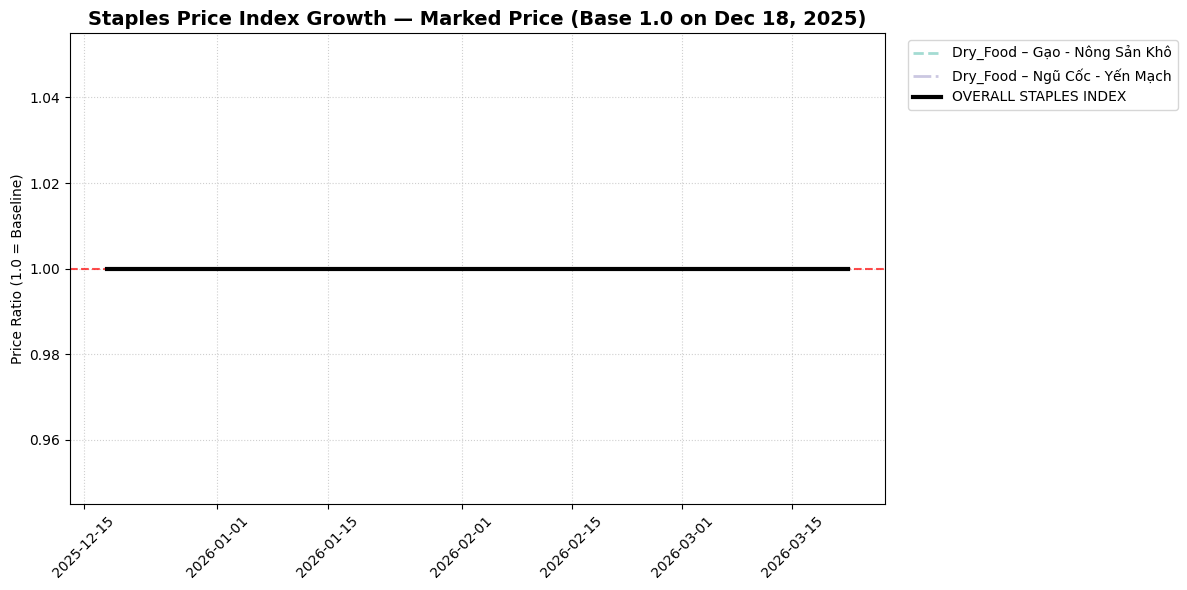

In [13]:
# --- Staples daily cumulative index growth (from marked_price Jevons) ---
if 'Dry_Food' in cat_indices:
    dry_df = cat_indices['Dry_Food'].copy()
    dry_df['date'] = pd.to_datetime(dry_df['date'])
    dry_df = dry_df.sort_values('date')

    staple_available = [c for c in STAPLES if c in dry_df.columns]

    if staple_available:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

        colors = ['#8dd3c7', '#bebada']
        for i, col in enumerate(staple_available):
            s = dry_df.dropna(subset=[col])
            style = style_config.get_style(col)
            ax.plot(s['date'], s[col],
                    label=f"Dry_Food – {col}",
                    color=colors[i % len(colors)], linestyle=style['linestyle'],
                    linewidth=2, alpha=0.8)

        dry_df['staples_avg'] = dry_df[staple_available].mean(axis=1)
        valid_avg = dry_df.dropna(subset=['staples_avg'])
        ax.plot(valid_avg['date'], valid_avg['staples_avg'],
                label='OVERALL STAPLES INDEX', color='black', linewidth=3, zorder=10)

        ax.set_title('Staples Price Index Growth — Marked Price (Base 1.0 on Dec 18, 2025)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Price Ratio (1.0 = Baseline)')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print('[WARN] Staple columns not found in Dry_Food cat_indices.')
else:
    print('[WARN] Dry_Food not in cat_indices.')

Saved: marked_price_staples_mom_comparison.png


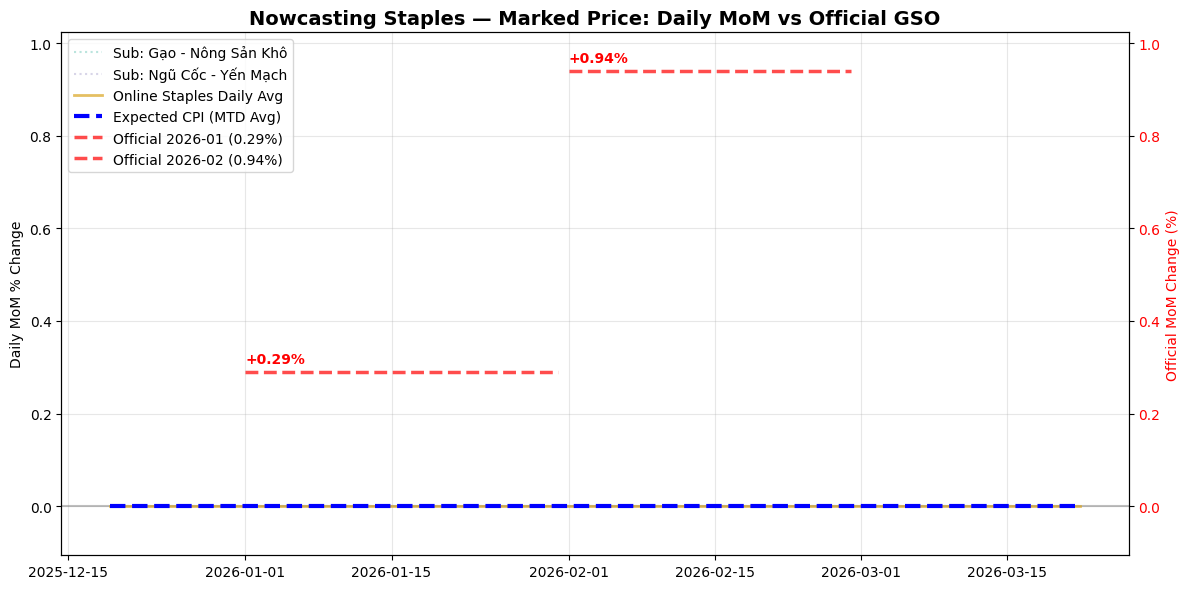

In [14]:
# --- Staples: daily MoM % + MTD expected CPI ---
if 'Dry_Food' in cat_indices and staple_available:
    dry_df2 = cat_indices['Dry_Food'].copy()
    dry_df2['date'] = pd.to_datetime(dry_df2['date'])
    dry_df2 = dry_df2.sort_values('date').reset_index(drop=True)

    # Daily MoM % from chain-link index: ratio[t] = index[t] / index[t-1]
    for col in staple_available:
        dry_df2[col + '_pct'] = (dry_df2[col] / dry_df2[col].shift(1) - 1) * 100

    pct_cols = [c + '_pct' for c in staple_available]
    dry_df2['staples_avg_pct'] = dry_df2[pct_cols].mean(axis=1)

    # MTD cumulative average
    dry_df2['expected_cpi'] = (
        dry_df2.groupby(dry_df2['date'].dt.to_period('M'))['staples_avg_pct']
               .transform(lambda x: x.expanding().mean())
    )

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.axhline(0, color='gray', linewidth=1.5, alpha=0.5)

    colors = ['#8dd3c7', '#bebada']
    for i, col in enumerate(staple_available):
        s = dry_df2.dropna(subset=[col + '_pct'])
        ax1.plot(s['date'], s[col + '_pct'],
                 label=f'Sub: {col}', color=colors[i], linewidth=1.5, alpha=0.6, linestyle=':')

    valid_avg = dry_df2.dropna(subset=['staples_avg_pct'])
    ax1.plot(valid_avg['date'], valid_avg['staples_avg_pct'],
             label='Online Staples Daily Avg', color='goldenrod', linewidth=2, alpha=0.7)

    valid_exp = dry_df2.dropna(subset=['expected_cpi'])
    ax1.plot(valid_exp['date'], valid_exp['expected_cpi'],
             label='Expected CPI (MTD Avg)', color='blue', linewidth=3, linestyle='--')

    ax1.set_ylabel('Daily MoM % Change')
    ax1.grid(True, alpha=0.3)

    ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'staples', 'red')
    align_axes(ax1, ax2_twin)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ax1.set_title('Nowcasting Staples — Marked Price: Daily MoM vs Official GSO', fontsize=14, fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUT / 'marked_price_staples_mom_comparison.png', dpi=300, bbox_inches='tight')
    print('Saved: marked_price_staples_mom_comparison.png')
    plt.show()

Saved: marked_price_other_food_mom_comparison.png


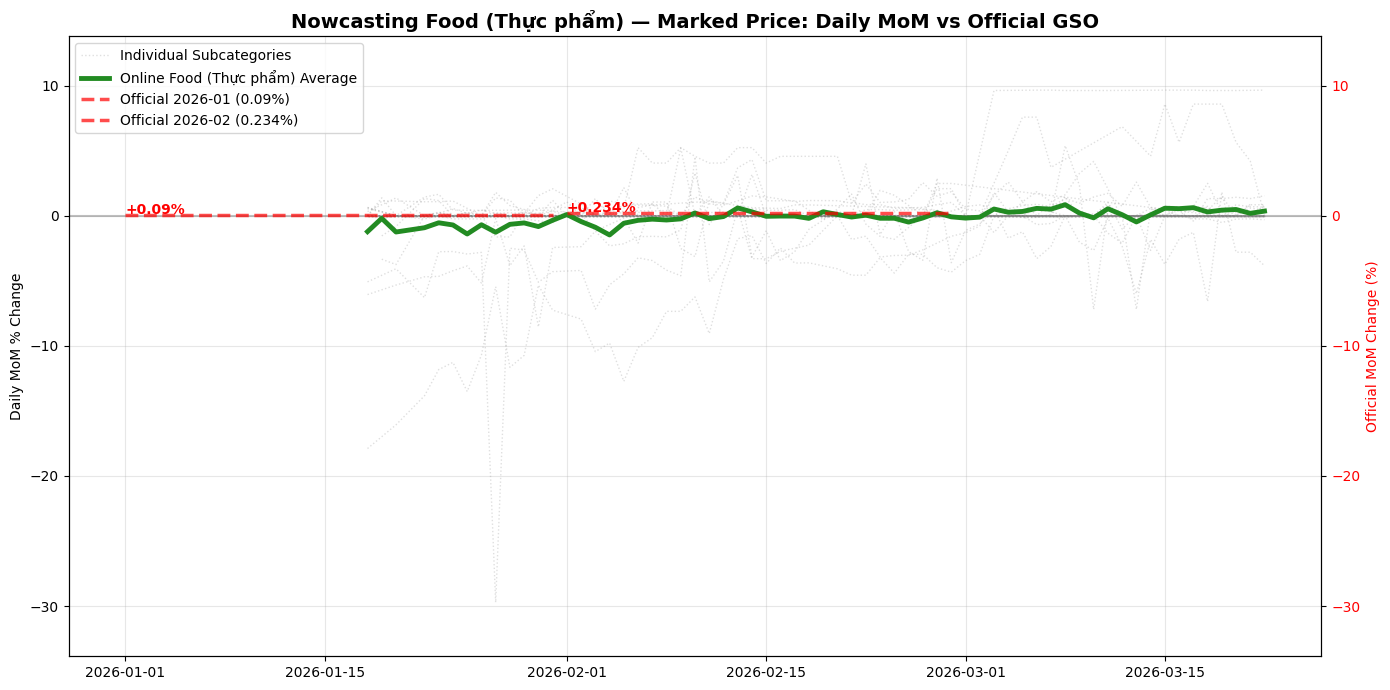

In [15]:
# --- Other Food: subcategory MoM breakdown ---
mom_plot_df = pd.read_csv(OUT / 'marked_price_other_food_mom_change.csv', parse_dates=['date'])
mom_sub_cols = [c for c in mom_plot_df.columns if c not in ['date', 'other_food_average']]

# Convert to % (MoM ratio → %)
for col in mom_sub_cols + ['other_food_average']:
    if col in mom_plot_df.columns:
        mom_plot_df[col] = (mom_plot_df[col] - 1) * 100

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.axhline(0, color='gray', linewidth=1.5, alpha=0.5)

for i, col in enumerate(mom_sub_cols):
    valid = mom_plot_df.dropna(subset=[col])
    label = 'Individual Subcategories' if i == 0 else '_nolegend_'
    ax1.plot(valid['date'], valid[col],
             label=label, color='gray', linewidth=1.0, alpha=0.25, linestyle=':')

if 'other_food_average' in mom_plot_df.columns:
    valid_avg = mom_plot_df.dropna(subset=['other_food_average'])
    ax1.plot(valid_avg['date'], valid_avg['other_food_average'],
             label='Online Food (Thực phẩm) Average', color='forestgreen', linewidth=3.5)

ax1.set_ylabel('Daily MoM % Change')
ax1.grid(True, alpha=0.3)
ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'thuc_pham', 'red')
align_axes(ax1, ax2_twin)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Nowcasting Food (Thực phẩm) — Marked Price: Daily MoM vs Official GSO', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT / 'marked_price_other_food_mom_comparison.png', dpi=300, bbox_inches='tight')
print('Saved: marked_price_other_food_mom_comparison.png')
plt.show()

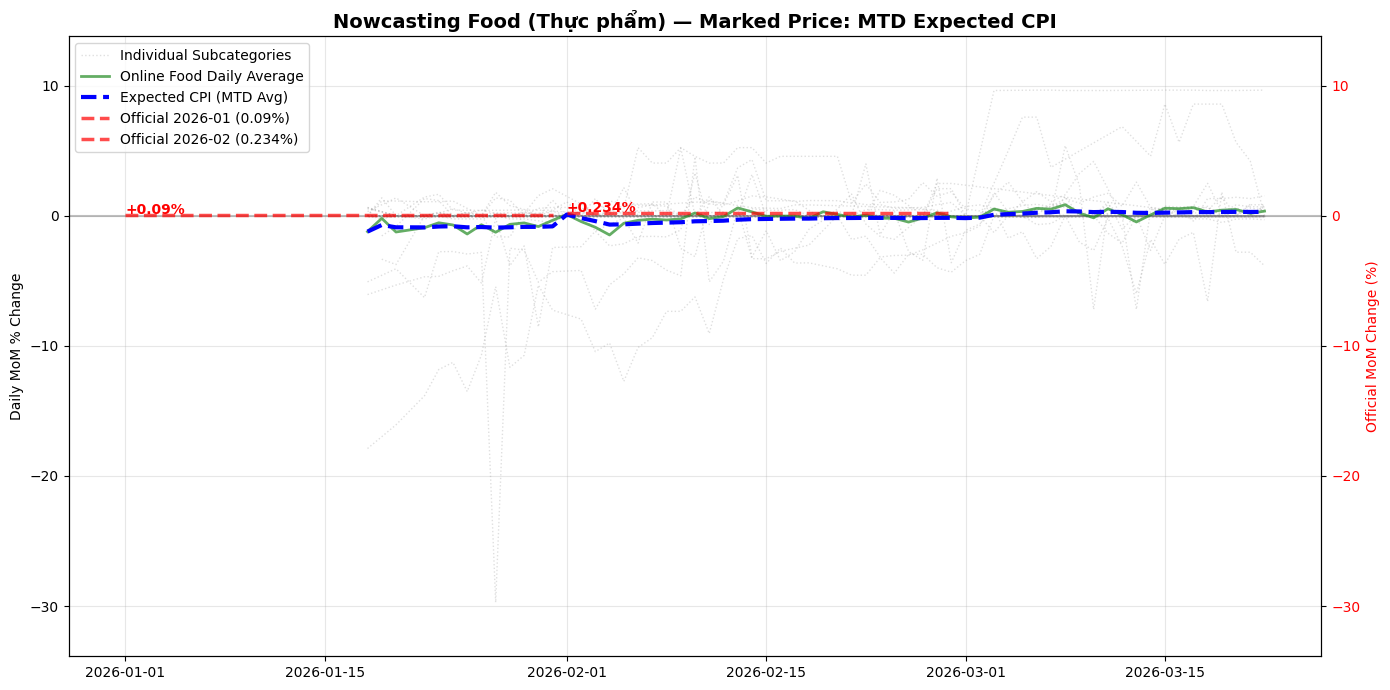

In [16]:
# --- Other Food: MTD expected CPI ---
mom_plot_df['expected_cpi'] = (
    mom_plot_df.groupby(mom_plot_df['date'].dt.to_period('M'))['other_food_average']
               .transform(lambda x: x.expanding().mean())
)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.axhline(0, color='gray', linewidth=1.5, alpha=0.5)

for i, col in enumerate(mom_sub_cols):
    valid = mom_plot_df.dropna(subset=[col])
    label = 'Individual Subcategories' if i == 0 else '_nolegend_'
    ax1.plot(valid['date'], valid[col],
             label=label, color='gray', linewidth=1.0, alpha=0.25, linestyle=':')

valid_avg = mom_plot_df.dropna(subset=['other_food_average'])
ax1.plot(valid_avg['date'], valid_avg['other_food_average'],
         label='Online Food Daily Average', color='forestgreen', linewidth=2, alpha=0.7)

valid_exp = mom_plot_df.dropna(subset=['expected_cpi'])
ax1.plot(valid_exp['date'], valid_exp['expected_cpi'],
         label='Expected CPI (MTD Avg)', color='blue', linewidth=3, linestyle='--')

ax1.set_ylabel('Daily MoM % Change')
ax1.grid(True, alpha=0.3)
ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'thuc_pham', 'red')
align_axes(ax1, ax2_twin)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Nowcasting Food (Thực phẩm) — Marked Price: MTD Expected CPI', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

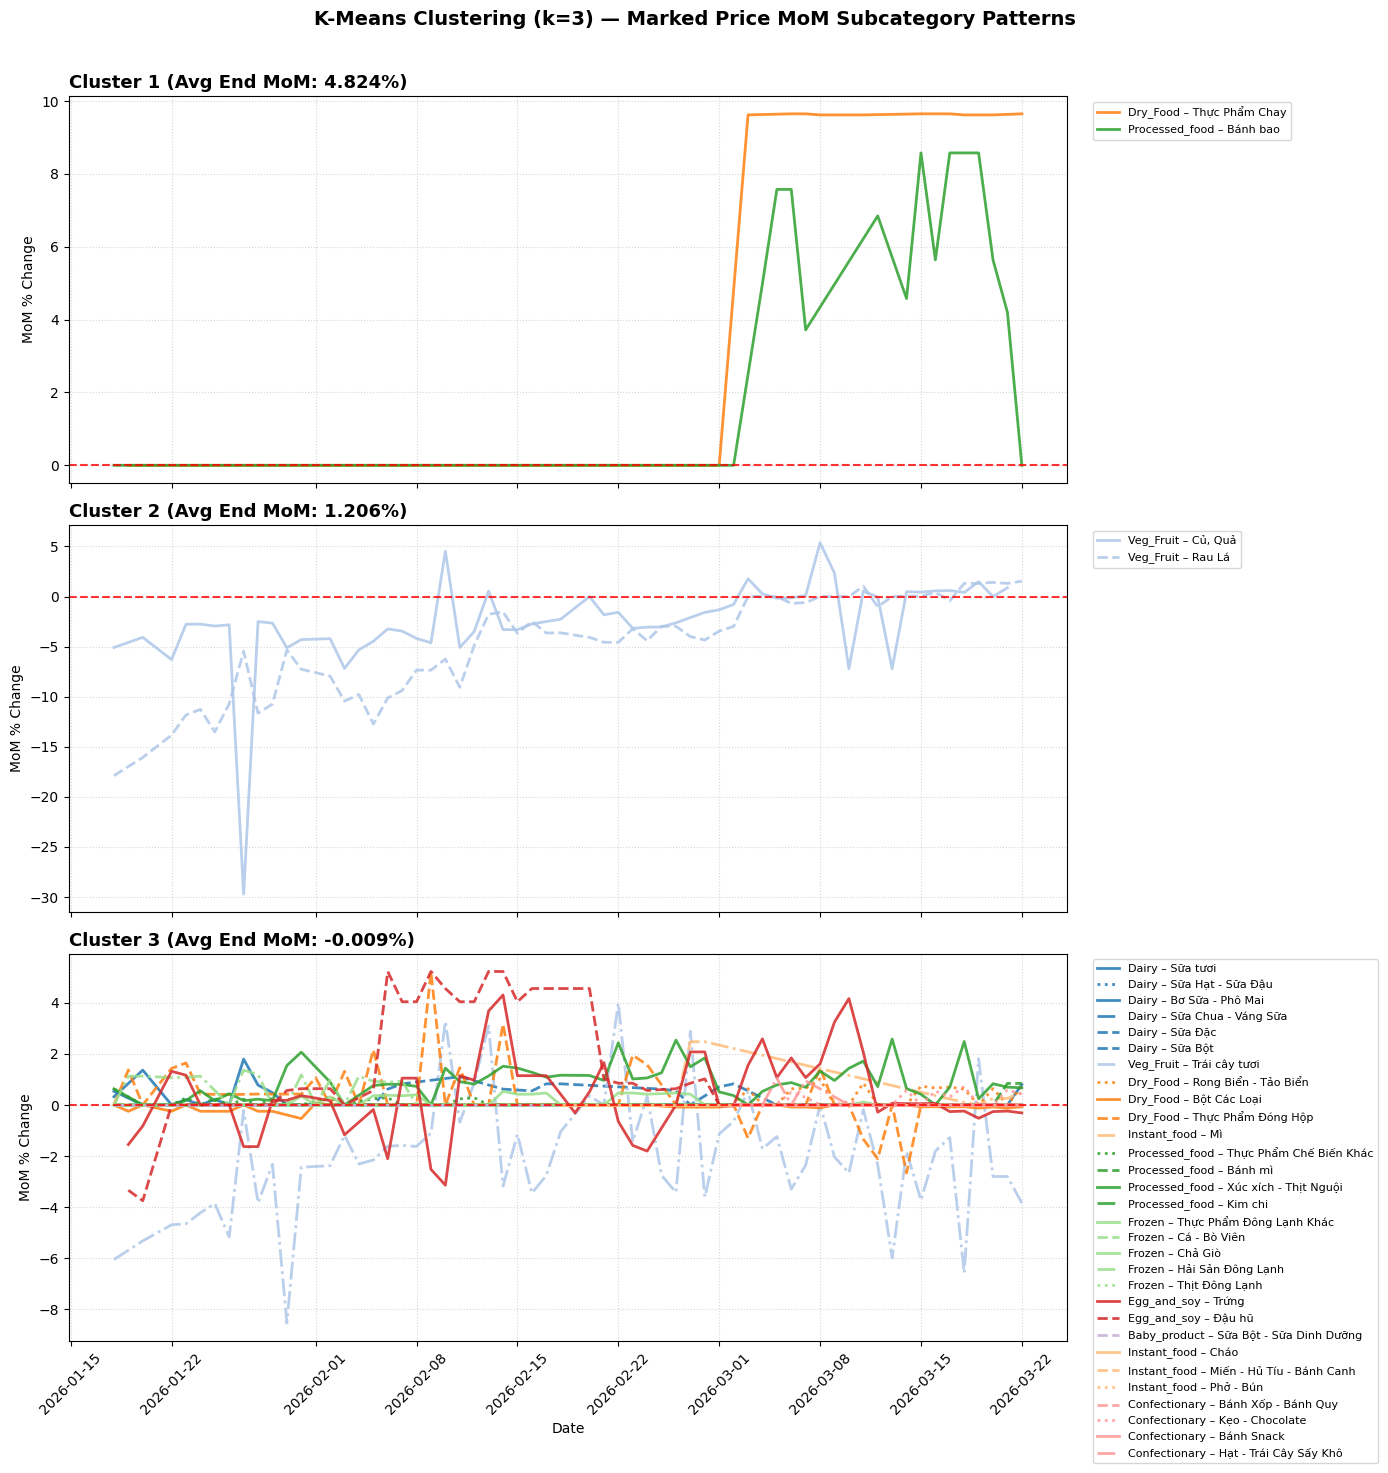

Saved: marked_price_subcategory_kmeans_groups.csv
date                       cluster
Thực Phẩm Chay                   0
Bánh bao                         0
Sữa tươi                         1
Thực Phẩm Đông Lạnh Khác         1
Cá - Bò Viên                     1
Chả Giò                          1
Hải Sản Đông Lạnh                1
Thịt Đông Lạnh                   1
Trứng                            1
Sữa Bột - Sữa Dinh Dưỡng         1
Cháo                             1
Miến - Hủ Tíu - Bánh Canh        1
Phở - Bún                        1
Bánh Xốp - Bánh Quy              1
Kẹo - Chocolate                  1
Đậu hũ                           1
Kim chi                          1
Xúc xích - Thịt Nguội            1
Bánh mì                          1
Thực Phẩm Chế Biến Khác          1
Mì                               1
Thực Phẩm Đóng Hộp               1
Bột Các Loại                     1
Rong Biển - Tảo Biển             1
Trái cây tươi                    1
Sữa Bột                          1
Sữa Đ

In [17]:
# --- K-Means clustering on marked-price MoM subcategory series ---
# Pivot: rows = subcategory, columns = date
pivot_df = mom_plot_df.set_index('date')[mom_sub_cols].T  # subcategory x date
pivot_df = pivot_df.ffill(axis=1).fillna(0)

n_clusters = 3
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
pivot_df['cluster'] = kmeans_model.fit_predict(pivot_df)

# Label clusters by ending-value to interpret direction
cluster_avg = pivot_df.groupby('cluster').mean().iloc[:, -1].sort_values(ascending=False)
cluster_labels = {
    cid: f'Cluster {i+1} (Avg End MoM: {cluster_avg[cid]:.3f}%)'
    for i, cid in enumerate(cluster_avg.index)
}

# Merge clusters back to long format
mom_long = mom_plot_df.melt(id_vars='date', value_vars=mom_sub_cols,
                             var_name='subcategory', value_name='mom_pct')
cluster_map = pivot_df[['cluster']].reset_index().rename(columns={'index': 'subcategory'})
mom_long = mom_long.merge(cluster_map, on='subcategory', how='left')

# Plot
fig, axes = plt.subplots(n_clusters, 1, figsize=(14, 5 * n_clusters), sharex=True)

for i, cid in enumerate(cluster_avg.index):
    ax = axes[i]
    subset = mom_long[mom_long['cluster'] == cid]

    for sub in subset['subcategory'].unique():
        sub_data = subset[subset['subcategory'] == sub].dropna(subset=['mom_pct'])
        if sub_data.empty:
            continue
        style_info = style_config.get_style(sub)
        ax.plot(sub_data['date'], sub_data['mom_pct'],
                label=f"{style_info['parent']} – {sub}",
                color=style_info['color'], linestyle=style_info['linestyle'],
                alpha=0.85, linewidth=2)

    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_title(cluster_labels[cid], fontsize=13, fontweight='bold', loc='left')
    ax.set_ylabel('MoM % Change')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.suptitle('K-Means Clustering (k=3) — Marked Price MoM Subcategory Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Export cluster assignments
cluster_out = pivot_df[['cluster']].rename(columns={'cluster': 'marked_price_cluster'})
cluster_out.to_csv(OUT / 'marked_price_subcategory_kmeans_groups.csv')
print('Saved: marked_price_subcategory_kmeans_groups.csv')
print(pivot_df[['cluster']].sort_values('cluster'))